# PVT Table Interpolation

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from scipy.interpolate import RegularGridInterpolator


sys.path.append(str(Path.cwd().resolve().parent.parent))
from rsimpy.cmg.datreader import dat_pvt
from rsimpy.cmg.datreader.dat_parser import DatParser

In [2]:
file_path = Path('../../SimModels/Unisim_iv_2024/dat_bo/base_case_bo.dat')
parser = DatParser(ignore=['ROCKFLUID','INITIAL','NUMERICAL','RUN','GRID_keys'])
parser.process(file_path=file_path)
pvt = dat_pvt._read_data(parser.get())[0]

## Interpolation Functions

In [3]:
def interp_extrap(x, y, new_x, extrap=True):
    """
    Perform linear interpolation and extrapolation.

    Extrapolates using the two lowest or two largest points if new_x is outside x range.

    Parameters
    ----------
    x : array_like
        Known x-coordinates.
    y : array_like
        Known y-coordinates corresponding to x.
    new_x : array_like
        New x-coordinates where interpolation/extrapolation is desired.
    extrap : bool, optional
        If True, extrapolate outside the range of x. Default is True.

    Returns
    -------
    y_interp : ndarray
        Interpolated or extrapolated y-coordinates corresponding to new_x.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    new_x = np.asarray(new_x)

    if not np.all(np.diff(x) > 0):
        sort_indices = np.argsort(x)
        x = x[sort_indices]
        if not np.all(np.diff(x) > 0):
            raise ValueError("Input x must be strictly increasing.")
        y = y[sort_indices]

    y_interp = np.interp(new_x, x, y)
    if not extrap:
        return y_interp

    below = new_x < x[0]
    if np.any(below):
        slope = (y[1] - y[0]) / (x[1] - x[0])
        y_interp[below] = y[0] + slope * (new_x[below] - x[0])

    above = new_x > x[-1]
    if np.any(above):
        slope = (y[-1] - y[-2]) / (x[-1] - x[-2])
        y_interp[above] = y[-1] + slope * (new_x[above] - x[-1])
    return y_interp

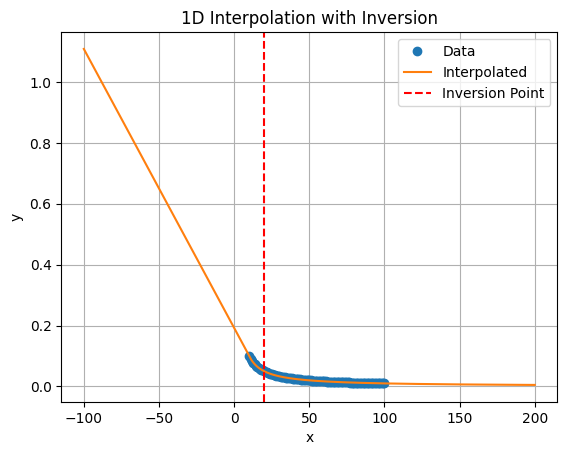

In [4]:
def alt_interp1d(x, y, x_new, x_inversion=-np.inf, inverse_smaller=True, extrap=True):
    """
    1D interpolation part linear, part linear to the inverse.

    Parameters
    ----------
    x : array_like
        The x-coordinates of the data points.
    y : array_like
        The y-coordinates of the data points.
    x_new : array_like
        The x-coordinates where the interpolation is evaluated.
    x_inversion : float, optional
        The x-coordinate where the interpolation switches from linear to inverse.
        Default is -np.inf, meaning no switch.
    inverse_smaller : bool, optional
        If True, the inverse interpolation is applied for x values smaller than x_inversion.
        If False, it is applied for x values larger than x_inversion.
        Default is True.
    extrap : bool, optional
        If True, extrapolation is performed for x values outside the range of x.
        If False, values outside the range will not be extrapolated.
        Default is True.
    Returns
    -------
    y_interp : array_like
        The interpolated y-coordinates corresponding to the input x values.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    if inverse_smaller:
        mask = x_new < x_inversion
    else:
        mask = x_new > x_inversion

    y_interp = np.zeros_like(x_new)
    y_interp[mask] = 1/interp_extrap(x, 1/(y+1E-20), x_new[mask], extrap=extrap)
    y_interp[~mask] = interp_extrap(x, y, x_new[~mask], extrap=extrap)

    return y_interp

x = np.linspace(10, 100, 100)
y = 1/x
x_new = np.linspace(-100, 200, 5000)
y_interp = alt_interp1d(x, y, x_new, x_inversion=20, inverse_smaller=False, extrap=True)
plt.plot(x, y, 'o', label='Data')
plt.plot(x_new, y_interp, label='Interpolated')
plt.axvline(20, color='red', linestyle='--', label='Inversion Point')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('1D Interpolation with Inversion')
plt.grid()
plt.show()

In [5]:
def interp_2D(x, y, new_x, interpolator=None, extrap=True):
    """Control extrapolation behavior for 2D interpolation."""
    x_ = []
    for i in range(len(x)):
        x_.append(np.asarray(x[i]))
    y = np.asarray(y)
    extrap = np.asarray(extrap, dtype=bool)
    new_x = np.asarray(new_x).copy()

    if interpolator is None:
        interpolator = RegularGridInterpolator(x_, y, bounds_error=False, fill_value=None)

    for i in range(new_x.shape[1]):
        if not extrap[i]:
            below = new_x[:,i] < x_[i][0]
            if np.any(below):
                new_x[below,i] = x_[i][0]
            above = new_x[:,i] > x_[i][-1]
            if np.any(above):
                new_x[above,i] = x_[i][-1]

    return interpolator(new_x)

# Example usage of interp_2D
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([10, 20, 30])
z = np.array([
    [10, 20, 30, 40, 50, 60],
    [110, 120, 130, 140, 150, 160],
    [210, 220, 230, 240, 250, 260],
    ]).T
new_x = np.array([[1.5, 25], [2, 500], [0,0]])
interpolator = RegularGridInterpolator((x, y), z, bounds_error=False, fill_value=None)
result = interp_2D((x, y), z, new_x, interpolator=interpolator, extrap=[True,False])
print("Interpolated result:", result)
result2 = interp_2D((x, y), z, new_x, extrap=[True,True])
print("Interpolated result:", result2)
result2 = interp_2D((x, y), z, new_x, extrap=[False,True])
print("Interpolated result:", result2)
result2 = interp_2D((x, y), z, new_x, extrap=[False,False])
print("Interpolated result:", result2)

Interpolated result: [165. 220.   0.]
Interpolated result: [ 165. 4920. -100.]
Interpolated result: [ 165. 4920.  -90.]
Interpolated result: [165. 220.  10.]


## Saturated Properties

To avoid negative values, extrapolation is performed to the inverse of the values when they are approaching zero.

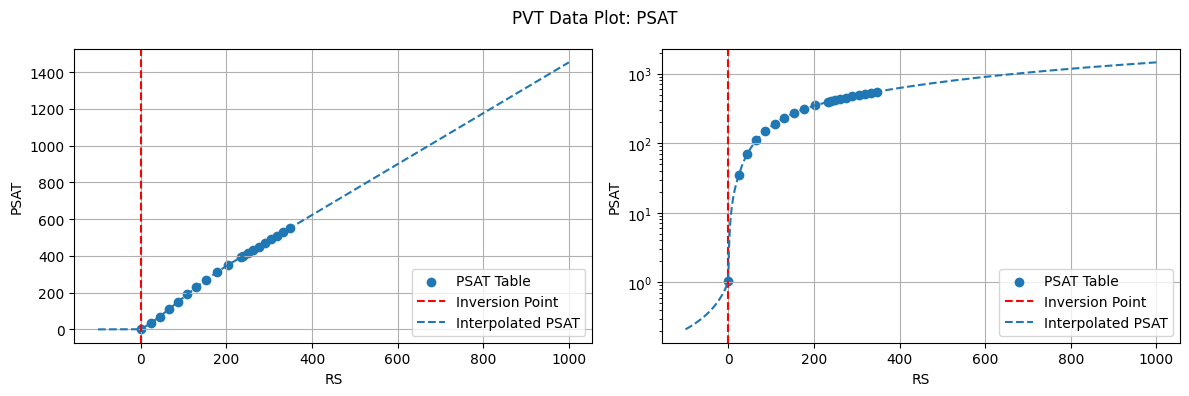

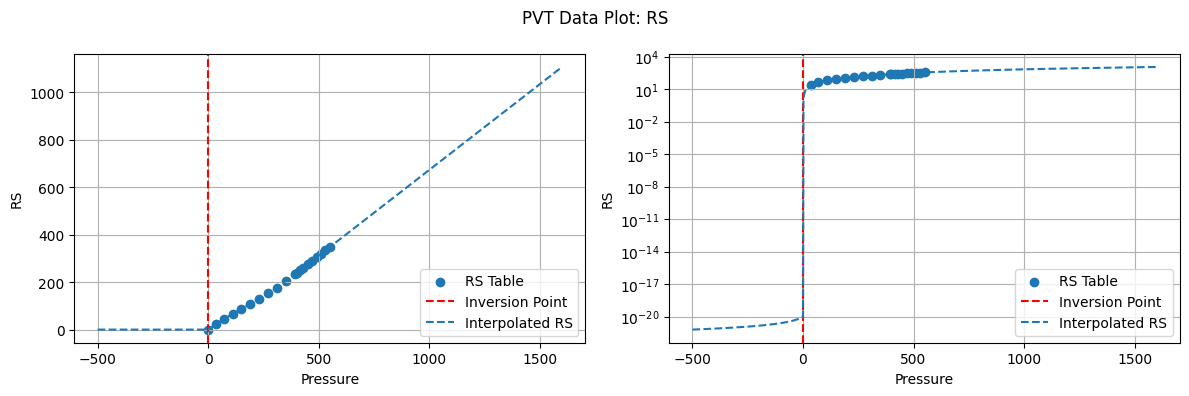

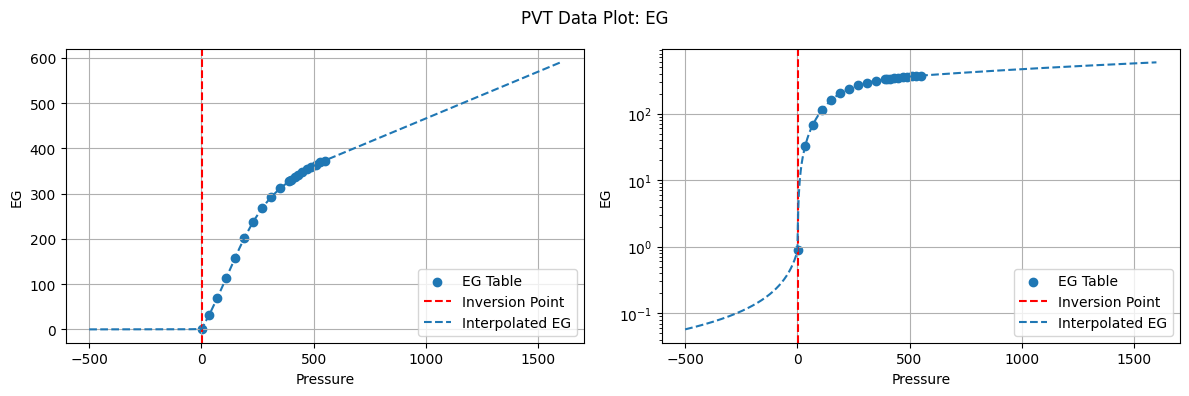

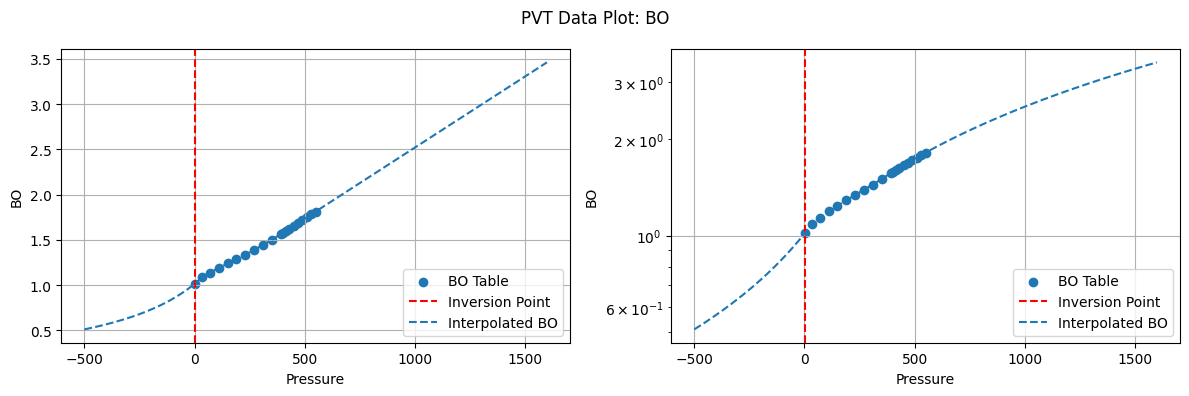

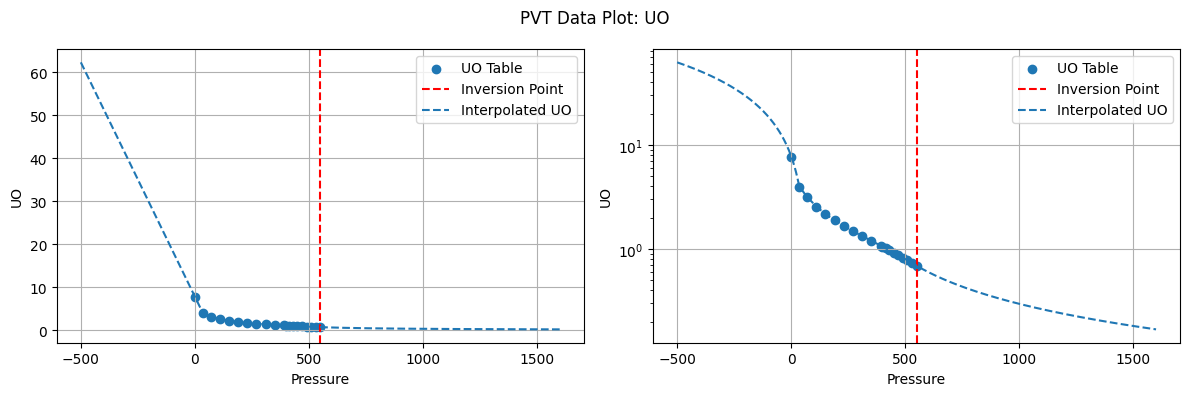

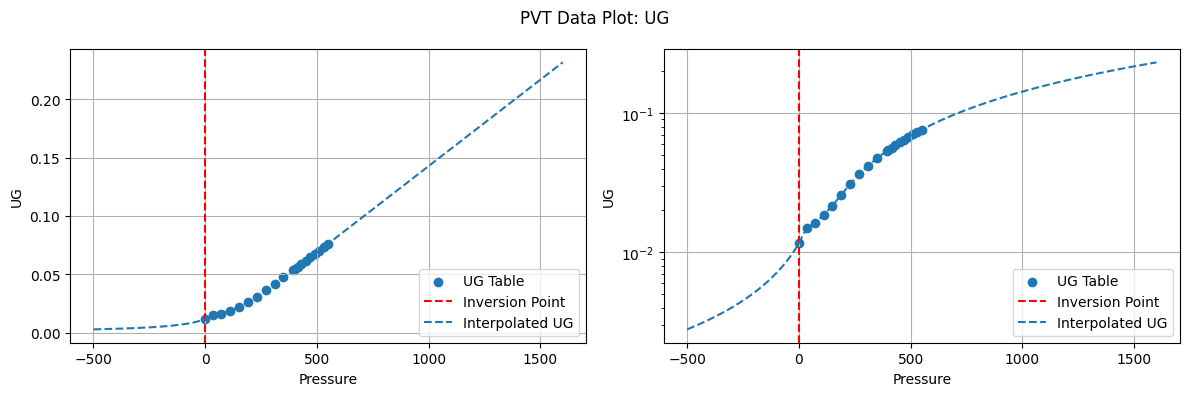

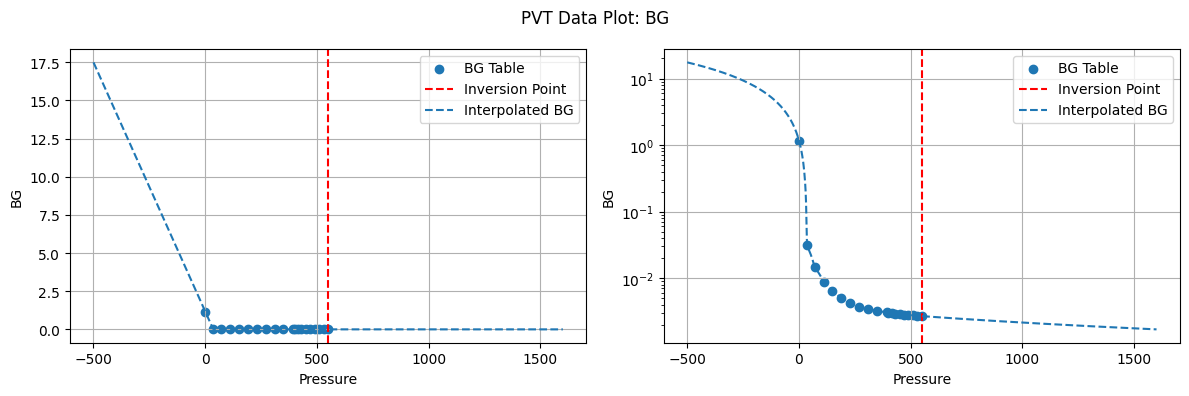

In [6]:
for col in ['PSAT', 'RS', 'EG', 'BO', 'UO', 'UG','BG']:
    _, axs = plt.subplots(1,2, figsize=(12, 4))

    p_extrap = np.linspace(-500, 1600, 1000)
    x_label = 'Pressure'
    if col == 'BG':
        v_ = 1/alt_interp1d(
            x=pvt['sat']['PRES'],
            y=pvt['sat']['EG'],
            x_new=p_extrap,
            x_inversion=pvt['sat']['PRES'][-1],
            inverse_smaller=(col!='UO'),
            extrap=True
            )
        for ax in axs:
            ax.scatter(pvt['sat']['PRES'], 1/pvt['sat']['EG'], label=f'{col} Table', marker='o')
            ax.axvline(pvt['sat']['PRES'][-1], color='red', linestyle='--', label='Inversion Point')
    elif col == 'PSAT':
        p_extrap = np.linspace(-100, 1000, 1000)
        v_ = alt_interp1d(
            x=pvt['sat']['RS'],
            y=pvt['sat']['PRES'],
            x_new=p_extrap,
            x_inversion=pvt['sat']['RS'][0],
            inverse_smaller=True,
            extrap=True
            )
        x_label = 'RS'
        for ax in axs:
            ax.scatter(pvt['sat']['RS'], pvt['sat']['PRES'], label=f'{col} Table', marker='o')
            ax.axvline(pvt['sat']['RS'][0], color='red', linestyle='--', label='Inversion Point')
    else:
        i = -1 if col == 'UO' else 0
        v_ = alt_interp1d(
            x=pvt['sat']['PRES'],
            y=pvt['sat'][col],
            x_new=p_extrap,
            x_inversion=pvt['sat']['PRES'][i],
            inverse_smaller=(col!='UO'),
            extrap=True
            )
        for ax in axs:
            ax.scatter(pvt['sat']['PRES'], pvt['sat'][col], label=f'{col} Table', marker='o')
            ax.axvline(pvt['sat']['PRES'][i], color='red', linestyle='--', label='Inversion Point')

    for ax in axs:
        ax.plot(p_extrap, v_, label=f'Interpolated {col}', linestyle='--', markersize=2) #, marker='*'
        ax.set_xlabel(x_label)
        ax.set_ylabel(col)
        ax.grid()
        ax.legend()
    axs[1].set_yscale('log')

    plt.suptitle(f'PVT Data Plot: {col}')
    plt.tight_layout()
    plt.show()

## Inverse Saturated Properties

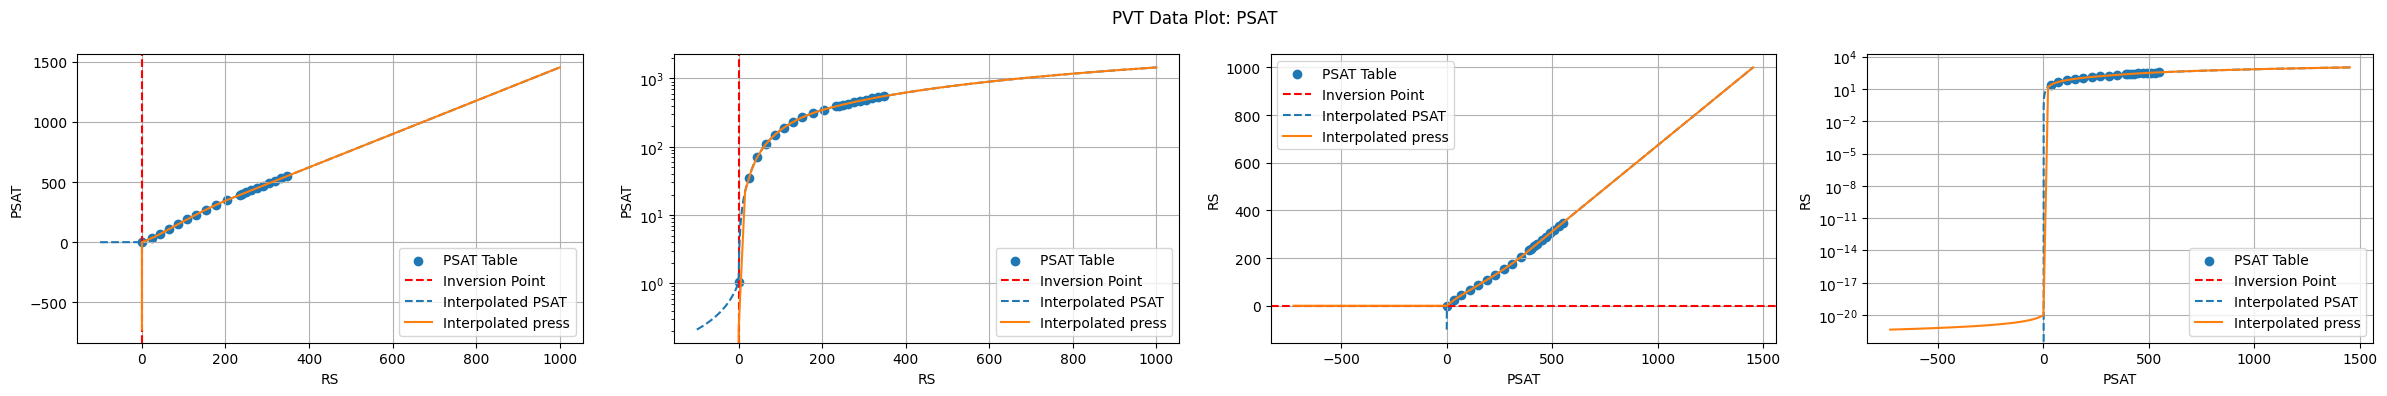

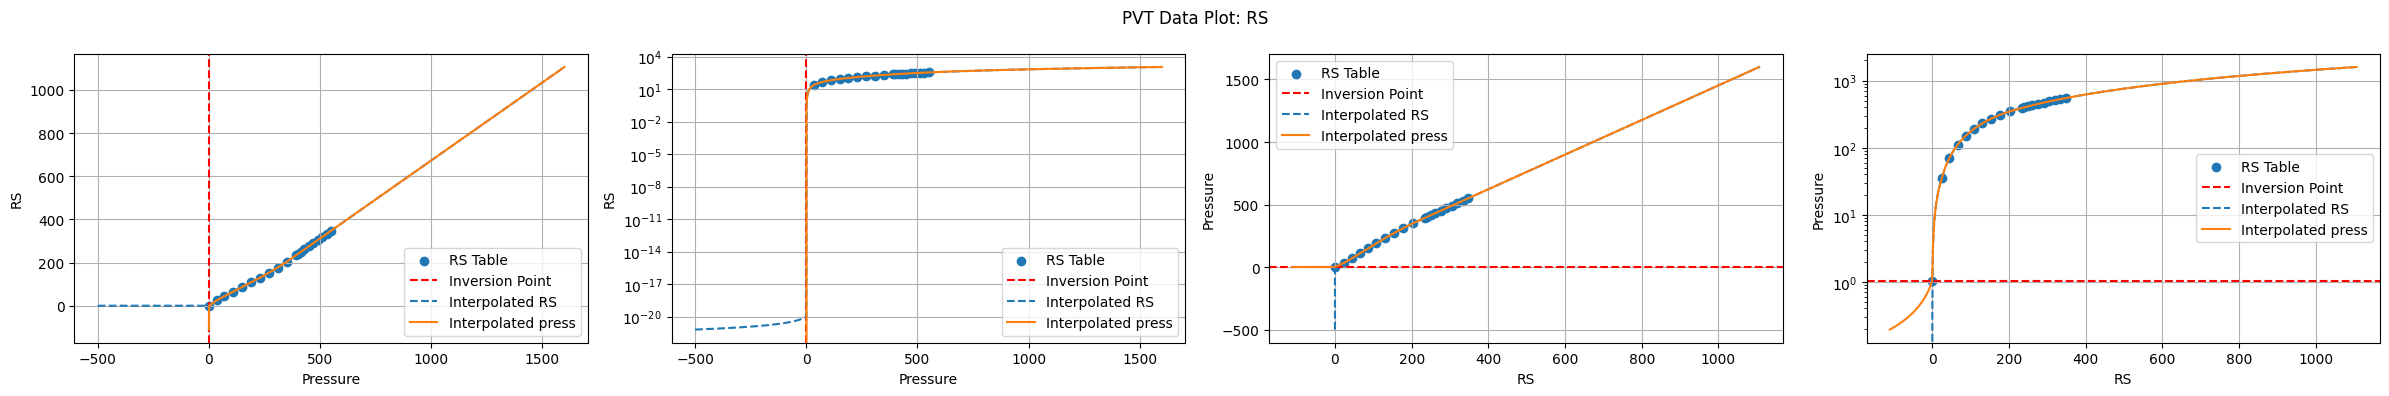

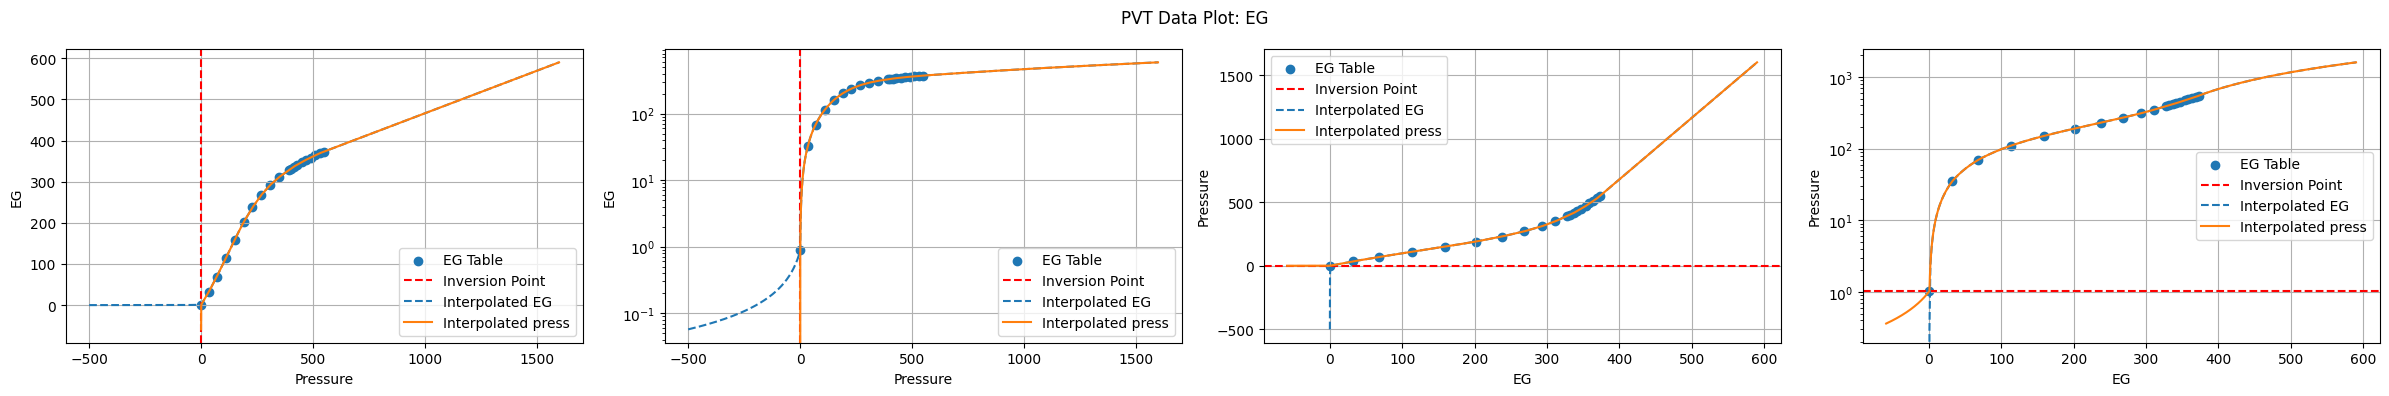

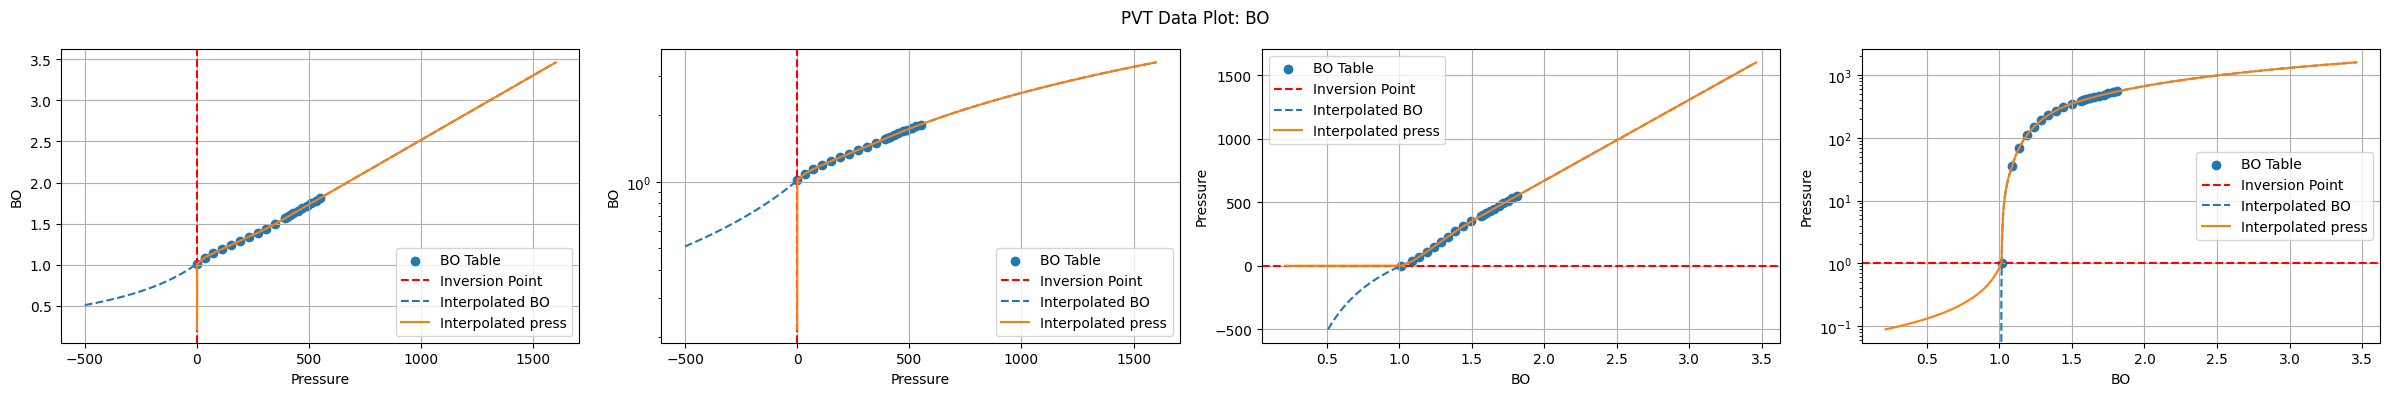

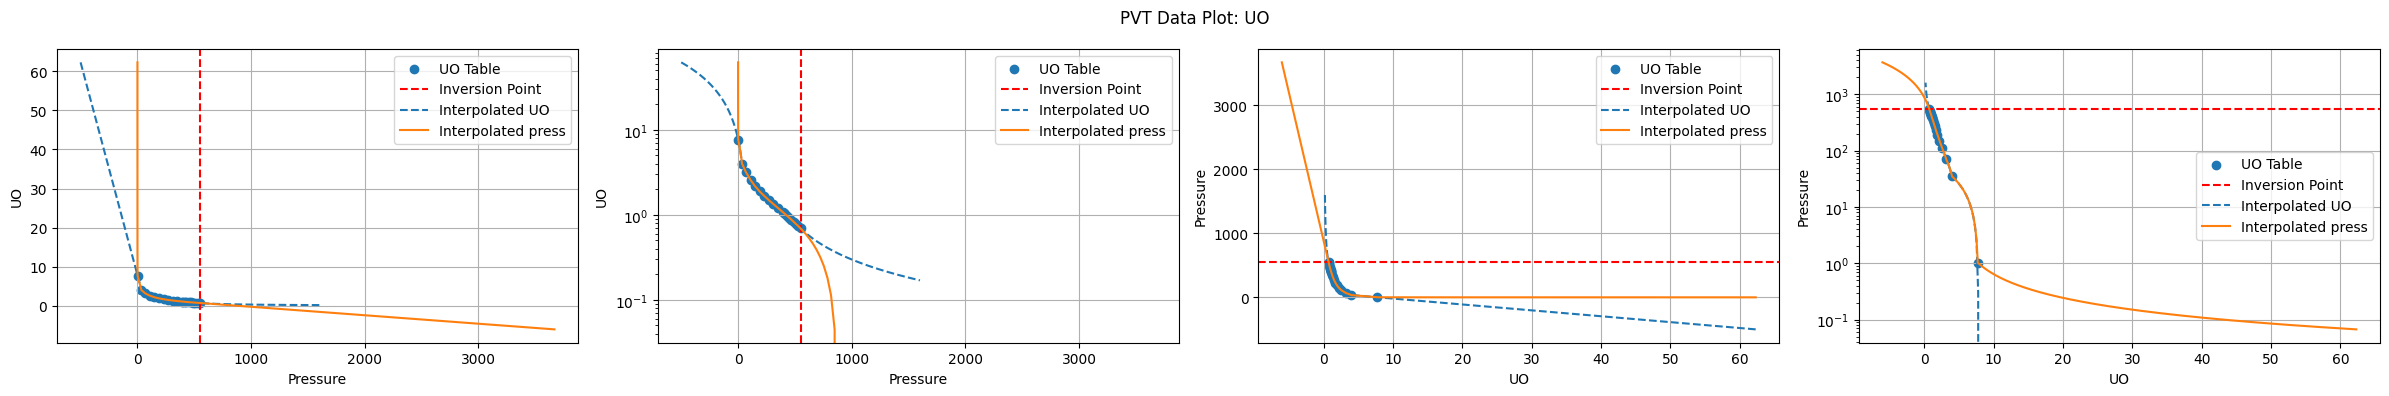

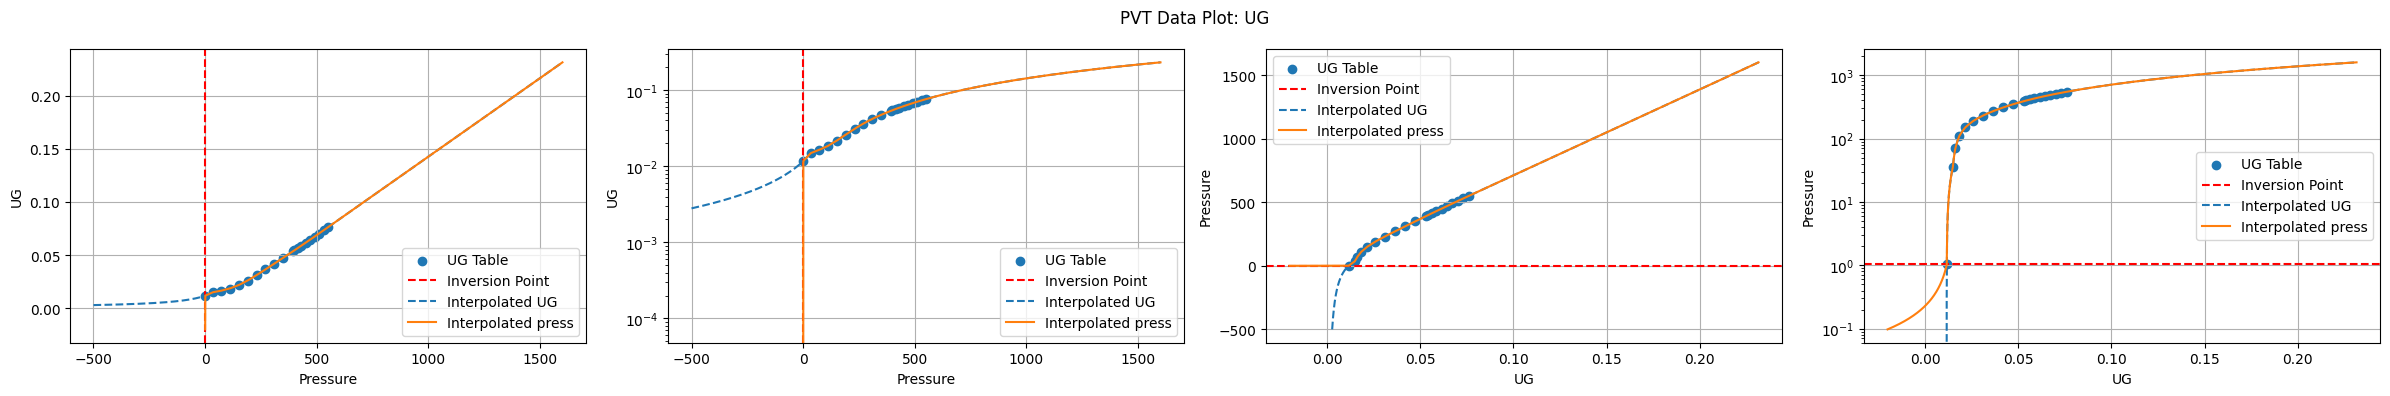

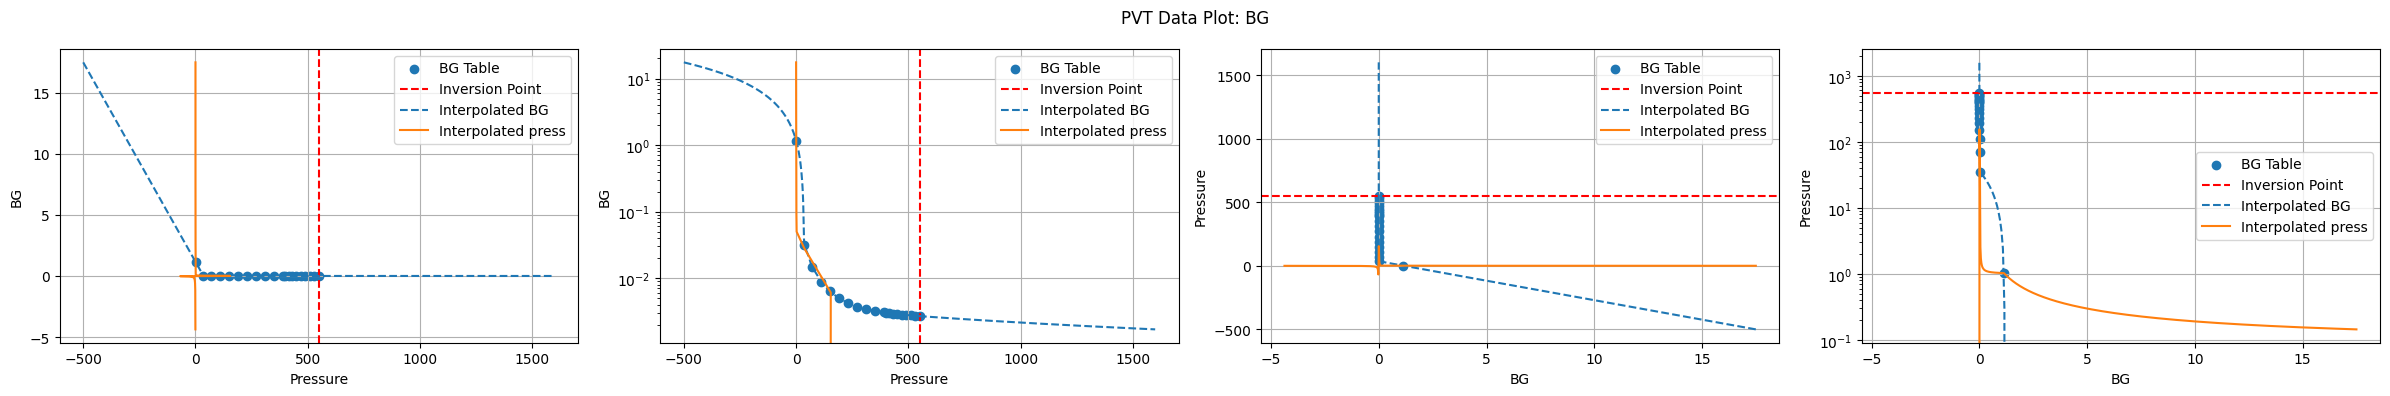

In [7]:
for col in ['PSAT', 'RS', 'EG', 'BO', 'UO', 'UG','BG']:
    _, axs = plt.subplots(1,4, figsize=(24, 4))

    p_extrap = np.linspace(-500, 1600, 1000)
    x_label = 'Pressure'
    if col == 'BG':
        v_ = 1/alt_interp1d(
            x=pvt['sat']['PRES'],
            y=pvt['sat']['EG'],
            x_new=p_extrap,
            x_inversion=pvt['sat']['PRES'][-1],
            inverse_smaller=True,
            extrap=True
            )

        v_extrap = np.linspace(v_.min() - (v_.max() - v_.min())*0.25, v_.max(), 1000)
        p_ = alt_interp1d(
            x=pvt['sat']['EG'],
            y=pvt['sat']['PRES'],
            x_new=1/v_extrap,
            x_inversion=pvt['sat']['EG'].min(),
            inverse_smaller=False,
            extrap=True
            )
        for ax in axs[:2]:
            ax.scatter(pvt['sat']['PRES'], 1/pvt['sat']['EG'], label=f'{col} Table', marker='o')
            ax.axvline(pvt['sat']['PRES'][-1], color='red', linestyle='--', label='Inversion Point')
        for ax in axs[2:]:
            ax.scatter(1/pvt['sat']['EG'], pvt['sat']['PRES'], label=f'{col} Table', marker='o')
            ax.axhline(pvt['sat']['PRES'][-1], color='red', linestyle='--', label='Inversion Point')

    elif col == 'PSAT':
        p_extrap = np.linspace(-100, 1000, 1000)
        v_ = alt_interp1d(
            x=pvt['sat']['RS'],
            y=pvt['sat']['PRES'],
            x_new=p_extrap,
            x_inversion=pvt['sat']['RS'][0],
            inverse_smaller=True,
            extrap=True
            )
        x_label = 'RS'

        v_extrap = np.linspace(v_.min() - (v_.max() - v_.min())*0.5, v_.max(), 100)
        p_ = alt_interp1d(
            x=pvt['sat']['PRES'],
            y=pvt['sat']['RS'],
            x_new=v_extrap,
            x_inversion=pvt['sat']['PRES'].min(),
            inverse_smaller=True,
            extrap=True
            )

        for ax in axs[:2]:
            ax.scatter(pvt['sat']['RS'], pvt['sat']['PRES'], label=f'{col} Table', marker='o')
            ax.axvline(pvt['sat']['RS'][0], color='red', linestyle='--', label='Inversion Point')
        for ax in axs[2:]:
            ax.scatter(pvt['sat']['PRES'], pvt['sat']['RS'], label=f'{col} Table', marker='o')
            ax.axhline(pvt['sat']['RS'][0], color='red', linestyle='--', label='Inversion Point')

    else:
        i = -1 if col == 'UO' else 0
        v_ = alt_interp1d(
            x=pvt['sat']['PRES'],
            y=pvt['sat'][col],
            x_new=p_extrap,
            x_inversion=pvt['sat']['PRES'][i],
            inverse_smaller=(col!='UO'),
            extrap=True
            )

        v_extrap = np.linspace(v_.min() - (v_.max() - v_.min())*0.1, v_.max(), 1000)
        p_ = alt_interp1d(
            x=pvt['sat'][col],
            y=pvt['sat']['PRES'],
            x_new=v_extrap,
            x_inversion=pvt['sat'][col][0],
            inverse_smaller=(col!='UO'),
            extrap=True
            )

        for ax in axs[:2]:
            ax.scatter(pvt['sat']['PRES'], pvt['sat'][col], label=f'{col} Table', marker='o')
            ax.axvline(pvt['sat']['PRES'][i], color='red', linestyle='--', label='Inversion Point')
        for ax in axs[2:]:
            ax.scatter(pvt['sat'][col], pvt['sat']['PRES'], label=f'{col} Table', marker='o')
            ax.axhline(pvt['sat']['PRES'][i], color='red', linestyle='--', label='Inversion Point')

    for ax in axs[:2]:
        ax.plot(p_extrap, v_, label=f'Interpolated {col}', linestyle='--', markersize=2)
        ax.plot(p_, v_extrap, label=f'Interpolated press', linestyle='-', markersize=2)
        ax.set_xlabel(x_label)
        ax.set_ylabel(col)
        ax.grid()
        ax.legend()

    for ax in axs[2:]:
        ax.plot(v_, p_extrap, label=f'Interpolated {col}', linestyle='--', markersize=2)
        ax.plot(v_extrap, p_, label=f'Interpolated press', linestyle='-', markersize=2)
        ax.set_xlabel(col)
        ax.set_ylabel(x_label)
        ax.grid()
        ax.legend()

    axs[1].set_yscale('log')
    axs[3].set_yscale('log')

    plt.suptitle(f'PVT Data Plot: {col}')
    plt.tight_layout()
    plt.show()

## Subsaturated Properties

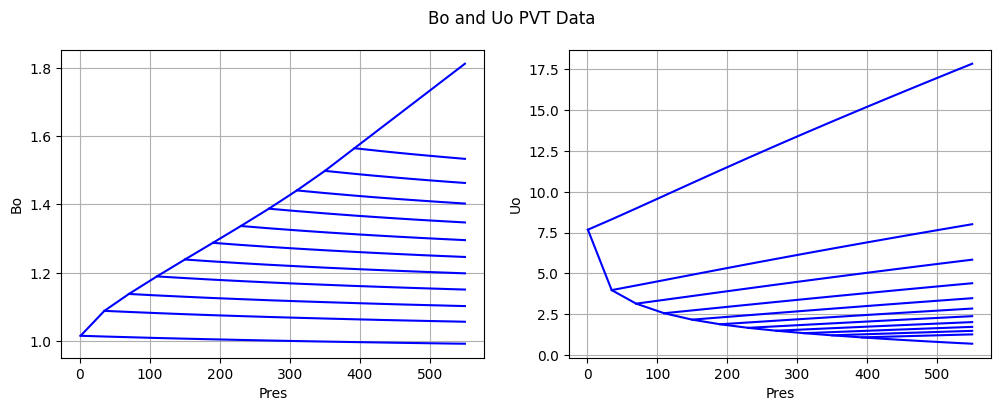

In [8]:
def bo_plot(p='b', ax=None):
    if ax is None:
        _, ax = plt.subplots(1,1)
    ax.plot(pvt['sat']['PRES'], pvt['sat'][f'{p.upper()}O'], color='b')
    for sub_sat in pvt[f'{p.lower()}ot'].values():
        ax.plot(sub_sat['PRES'], sub_sat['val'], color='b')
    ax.set_xlabel('Pres')
    ax.set_ylabel(f'{p.upper()}o')
    ax.grid()

_, axes = plt.subplots(1,2, figsize=(12,4))
bo_plot('b', ax=axes[0])
bo_plot('u', ax=axes[1])
plt.suptitle('Bo and Uo PVT Data')
plt.show()

For each subsaturated table (known Rs and $p_{sat}$), it is assumed a linear relationship between the subsaturation: $\Delta p = p-p_{sat}$, and the inverse of the compressibility: $c^{-1} = Bo \frac{dP}{dBo}$. $\frac{dP}{dBo}$ is aproximated using forward differences: $\frac{dP}{dBo} \approx \frac{p_{i+1} - p_i}{Bo_{i+1} - Bo_i}$.

The slope of these correlations ($\alpha$) is used to calculate for each point $\beta = [(Bo/Bo_{sat})^{\alpha} - 1] / (\alpha * \Delta P)$. The choice of $\beta$ as the interpolation factor is due to the fact that it, usually, is approximately constant for a given $p_{sat}$.

For any interpolation it is needed $\alpha = f(p_{sat})$ and $\beta = f(p_{sat}$, $\Delta P)$.

To obtain the resulting interpolation: $Bo = Bo_{sat} * (\alpha \beta \Delta P + 1)^{1/\alpha}$.

The same logic applies to $\mu_o$.

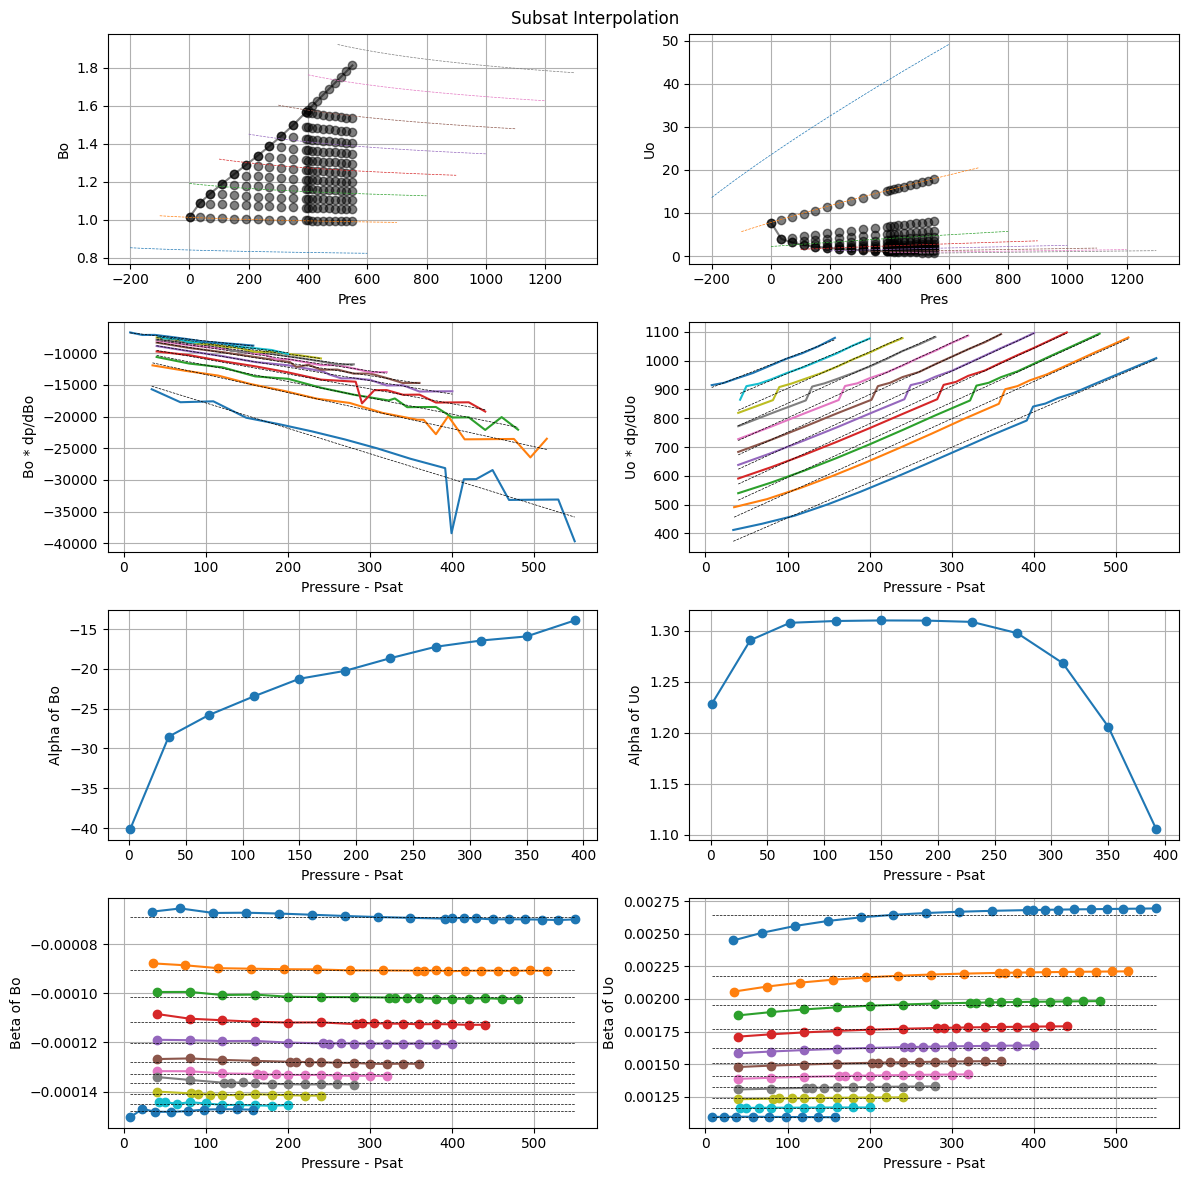

In [9]:
EPS = 1e-6
psat = {}
vsat = {}
alphas = {}
betas = {}
all_betas = {}
all_deltas = {}
_, axes = plt.subplots(4,2, figsize=(12, 12))
axes = axes.flatten()
for ii, p in enumerate(['b','u']):
    axes[ii].plot(pvt['sat']['PRES'], pvt['sat'][f'{p.upper()}O'], '-o', color='k', alpha=0.5)
    for sub_sat in pvt[f'{p.lower()}ot'].values():
        axes[ii].plot(sub_sat['PRES'], sub_sat['val'], 'o', color='k', alpha=0.5)
    axes[ii].set_xlabel('Pres')
    axes[ii].set_ylabel(f'{p.upper()}o')

    psat[p] = list()
    vsat[p] = list()
    alphas[p] = list()
    betas[p] = list()
    for sub_sat in pvt[f'{p.lower()}ot'].values():
        psat[p].append(sub_sat['PRES'][0])
        vsat[p].append(sub_sat['val'][0])

        d_pres = sub_sat['PRES'][1:] - sub_sat['PRES'][:-1]
        d_val = sub_sat['val'][1:] - sub_sat['val'][:-1]
        delta_p = sub_sat['PRES'][1:] - sub_sat['PRES'][0]
        inv_c = sub_sat['val'][:-1] * d_pres / d_val
        alpha, intercept, r_value, p_value, std_err = linregress(delta_p, inv_c)
        alphas[p].append([sub_sat['PRES'][0], alpha])

        beta = (np.power(sub_sat['val'][1:]/sub_sat['val'][0], alpha) - 1) / (alpha * delta_p)
        betas[p].append([delta_p, np.repeat(beta.mean(), delta_p.shape[0])])

        axes[ii+2].plot(delta_p, inv_c)
        axes[ii+2].plot(delta_p, alpha * delta_p + intercept, '--', linewidth=0.5, color='k')
        axes[ii+6].plot(delta_p, beta,'-o')

    alphas[p] = np.concatenate(alphas[p]).reshape(-1, 2).T
    axes[ii+4].plot(alphas[p][0], alphas[p][1], 'o-')

    all_deltas[p] = np.concatenate([x[0] for x in betas[p]])
    all_deltas[p] = np.unique(all_deltas[p])
    all_deltas[p] = np.sort(all_deltas[p])
    all_betas[p] = []
    for beta in betas[p]:
        beta_interp = interp_extrap(beta[0], beta[1], all_deltas[p], extrap=False)
        all_betas[p].append(beta_interp)

        axes[ii+6].plot(all_deltas[p], beta_interp,'--', linewidth=0.5, color='k')
    all_betas[p] = np.array(all_betas[p])

    beta_interp2d = RegularGridInterpolator((psat[p], all_deltas[p]), all_betas[p], bounds_error=False, fill_value=None)

    # Test extrapolation
    extrap_psat = np.linspace(-100, 600, 8)
    extrap_deltas = np.linspace(-100, 700, 100)
    if p == 'b':
        vs = interp_extrap(psat[p], np.array(vsat[p]), extrap_psat)
        vs_inv = 1/interp_extrap(psat[p], 1/np.array(vsat[p]), extrap_psat)
        vs[extrap_psat < psat[p][0]] = vs_inv[extrap_psat < psat[p][0]]

    elif p == 'u':
        vs = interp_extrap(psat[p], np.array(vsat[p]), extrap_psat)
        vs_inv = 1/interp_extrap(psat[p], 1/np.array(vsat[p]), extrap_psat)
        vs[extrap_psat > psat[p][-1]] = vs_inv[extrap_psat > psat[p][-1]]

    alpha = interp_extrap(alphas[p][0], alphas[p][1], extrap_psat, extrap=False)
    for pr, vs, alpha in zip(extrap_psat, vs, alpha):
        beta_interp = interp_2D(
            (psat[p], all_deltas[p]), all_betas[p],
            new_x=np.stack(([pr]*extrap_deltas.shape[0], extrap_deltas), axis=1),
            interpolator=beta_interp2d,
            extrap=[False, False])

        s = alpha * extrap_deltas * beta_interp + 1
        s[s < EPS] =  - EPS / extrap_deltas[s < EPS] # avoid negative values inside the power
        new_values = vs * np.power(s, 1/alpha)
        axes[ii].plot(extrap_deltas + pr, new_values, linewidth=0.5, linestyle='--')


    axes[ii+2].set_xlabel('Pressure - Psat')
    axes[ii+2].set_ylabel(f'{p.upper()}o * dp/d{p.upper()}o')
    axes[ii+4].set_ylabel(f'Alpha of {p.upper()}o')
    axes[ii+4].set_xlabel('Pressure - Psat')
    axes[ii+6].set_ylabel(f'Beta of {p.upper()}o')
    axes[ii+6].set_xlabel('Pressure - Psat')

for ax in axes:
    ax.grid()

plt.suptitle('Subsat Interpolation')
plt.tight_layout()
plt.show()

### Simpler Interpolation

Does not guarantee $\hat{y}(x_i)=y_i$, for the known $(x_i,y_i)$.

For each subsaturated table (known Rs and $p_{sat}$), it is assumed a linear relationship between the subsaturation: $\Delta p = p-p_{sat}$, and the inverse of the compressibility: $c^{-1} = Bo \frac{dP}{dBo}$. $\frac{dP}{dBo}$ is aproximated using forward differences: $\frac{dP}{dBo} \approx \frac{p_{i+1} - p_i}{Bo_{i+1} - Bo_i}$.

The slope of these correlations ($\alpha$) is used to calculate for each point $\beta = [(Bo/Bo_{sat})^{\alpha} - 1] / (\alpha * \Delta P)$. The mean $\beta$ is used as another interpolation factor is due to the fact that it, usually, is approximately constant for a given $p_{sat}$.

For any interpolation it is needed $\alpha = f(p_{sat})$ and $\beta = f(p_{sat}$)$.

To obtain the resulting interpolation: $Bo = Bo_{sat} * (\alpha \beta \Delta P + 1)^{1/\alpha}$.

The same logic applies to $\mu_o$.

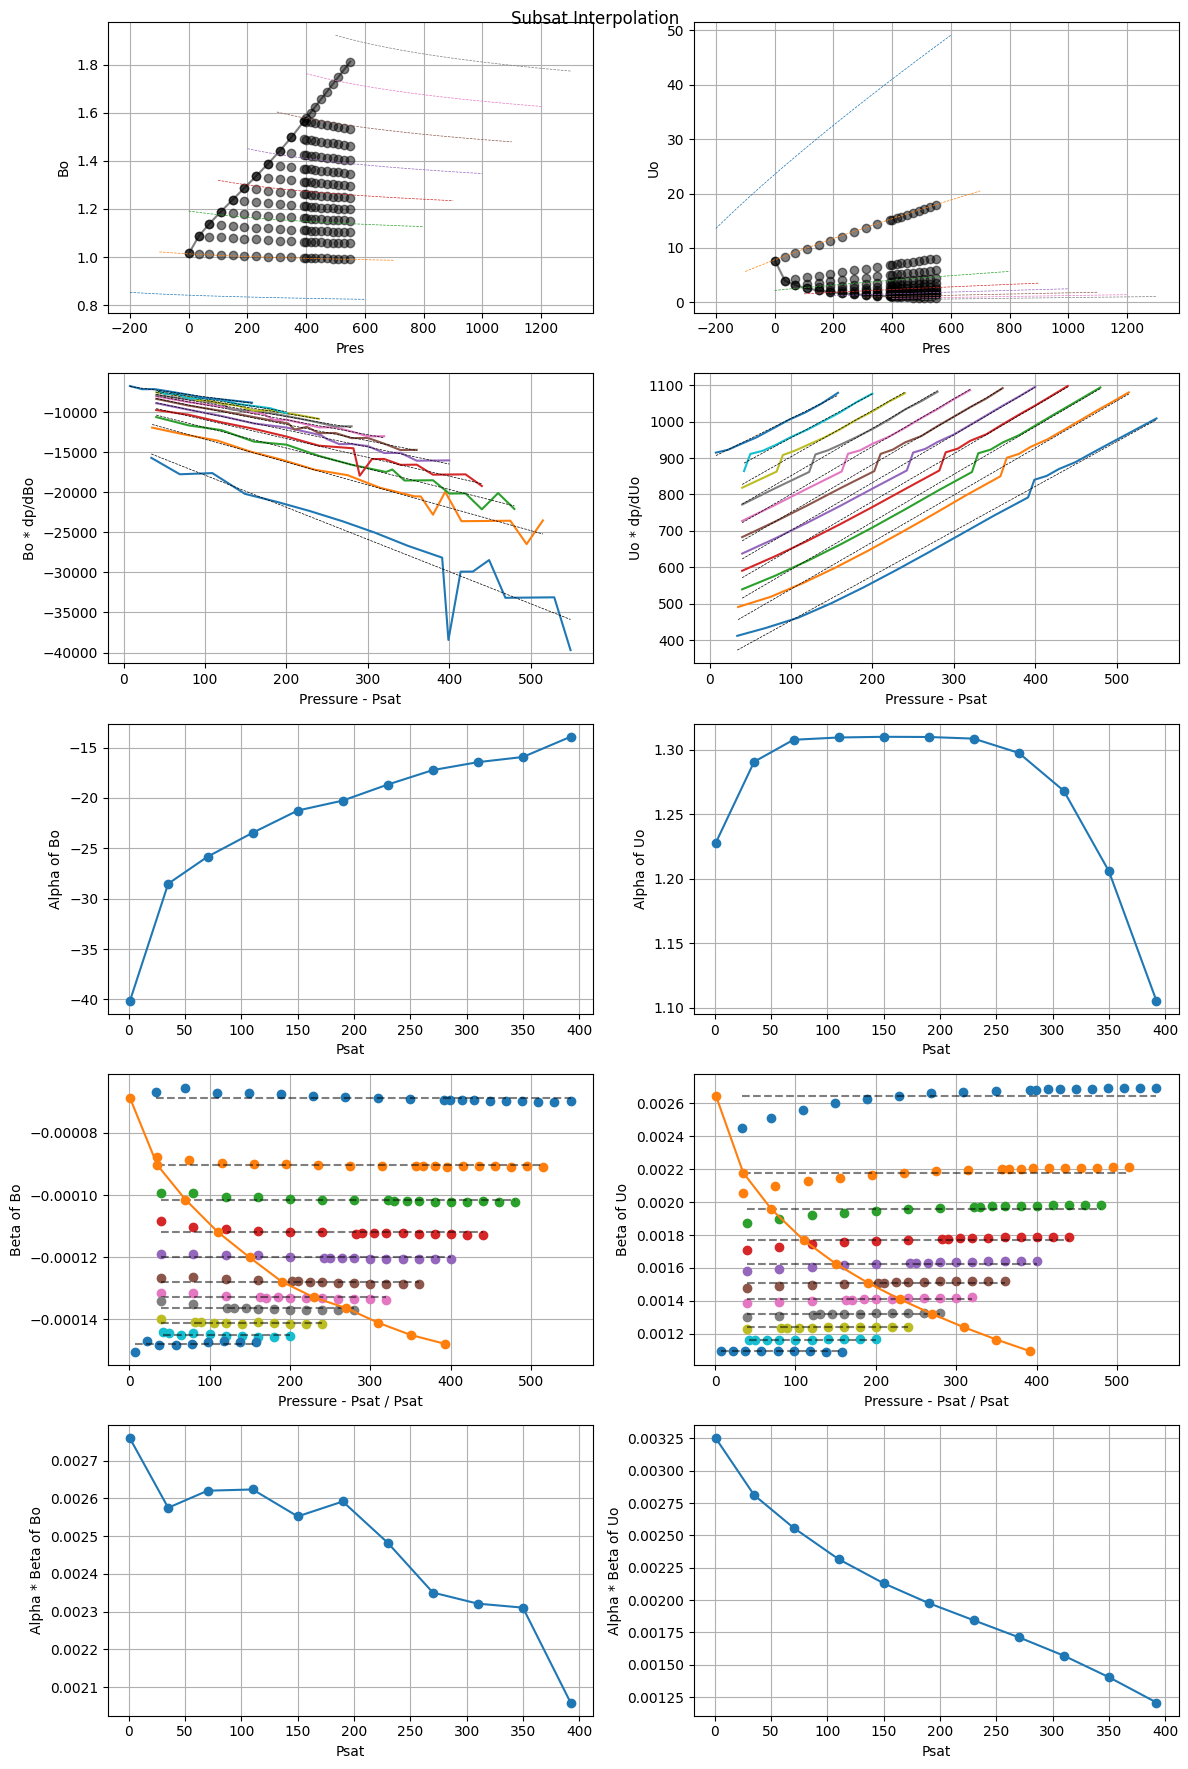

In [10]:
EPS = 1e-6
psat = {}
vsat = {}
alphas = {}
betas = {}
_, axes = plt.subplots(5,2, figsize=(12, 18))
axes = axes.flatten()
for ii, p in enumerate(['b','u']):
    axes[ii].plot(pvt['sat']['PRES'], pvt['sat'][f'{p.upper()}O'], '-o', color='k', alpha=0.5)
    for sub_sat in pvt[f'{p.lower()}ot'].values():
        axes[ii].plot(sub_sat['PRES'], sub_sat['val'], 'o', color='k', alpha=0.5)
    axes[ii].set_xlabel('Pres')
    axes[ii].set_ylabel(f'{p.upper()}o')

    psat[p] = list()
    vsat[p] = list()
    alphas[p] = list()
    betas[p] = list()
    for sub_sat in pvt[f'{p.lower()}ot'].values():
        psat[p].append(sub_sat['PRES'][0])
        vsat[p].append(sub_sat['val'][0])

        d_pres = sub_sat['PRES'][1:] - sub_sat['PRES'][:-1]
        d_val = sub_sat['val'][1:] - sub_sat['val'][:-1]
        delta_p = sub_sat['PRES'][1:] - sub_sat['PRES'][0]
        inv_c = sub_sat['val'][:-1] * d_pres / d_val
        alpha, intercept, r_value, p_value, std_err = linregress(delta_p, inv_c)
        alphas[p].append([sub_sat['PRES'][0], alpha])

        beta = (np.power(sub_sat['val'][1:]/sub_sat['val'][0], alpha) - 1) / (alpha * delta_p)
        betas[p].append([sub_sat['PRES'][0], beta.mean()])

        axes[ii+2].plot(delta_p, inv_c)
        axes[ii+2].plot(delta_p, alpha * delta_p + intercept, '--', linewidth=0.5, color='k')
        axes[ii+6].plot(delta_p, beta,'o')
        axes[ii+6].plot(delta_p, np.repeat(beta.mean(), delta_p.shape[0]), '--', color='k', alpha=0.5)

    alphas[p] = np.concatenate(alphas[p]).reshape(-1, 2).T
    betas[p] = np.concatenate(betas[p]).reshape(-1, 2).T
    axes[ii+4].plot(alphas[p][0], alphas[p][1], '-o')
    axes[ii+6].plot(betas[p][0], betas[p][1], '-o')
    axes[ii+8].plot(betas[p][0], alphas[p][1]*betas[p][1], '-o')

    # Test extrapolation
    extrap_psat = np.linspace(-100, 600, 8)
    extrap_deltas = np.linspace(-100, 700, 100)
    i_ = -1 if p == 'u' else 0
    vs = alt_interp1d(
        x=pvt['sat']['PRES'],
        y=pvt['sat'][f'{p.upper()}O'],
        x_new=extrap_psat,
        x_inversion=pvt['sat']['PRES'][i],
        inverse_smaller=(p=='b'),
        extrap=True
    )

    alpha = interp_extrap(alphas[p][0], alphas[p][1], extrap_psat, extrap=False)
    beta = interp_extrap(betas[p][0], betas[p][1], extrap_psat, extrap=False)
    for pr, vs, alpha, beta in zip(extrap_psat, vs, alpha, beta):
        s = alpha * extrap_deltas * beta + 1
        s[s < EPS] =  - EPS / extrap_deltas[s < EPS] # avoid negative values inside the power
        new_values = vs * np.power(s, 1/alpha)
        axes[ii].plot(extrap_deltas + pr, new_values, linewidth=0.5, linestyle='--')


    axes[ii+2].set_xlabel('Pressure - Psat')
    axes[ii+2].set_ylabel(f'{p.upper()}o * dp/d{p.upper()}o')
    axes[ii+4].set_ylabel(f'Alpha of {p.upper()}o')
    axes[ii+4].set_xlabel('Psat')
    axes[ii+6].set_ylabel(f'Beta of {p.upper()}o')
    axes[ii+6].set_xlabel('Pressure - Psat / Psat')
    axes[ii+8].set_ylabel(f'Alpha * Beta of {p.upper()}o')
    axes[ii+8].set_xlabel('Psat')

for ax in axes:
    ax.grid()

plt.suptitle('Subsat Interpolation')
plt.tight_layout()
plt.show()

### Test

In [11]:
pres_   = np.array([4.564797468427036620e+02, 4.534467284317274220e+02, 4.467189515532826931e+02, 4.645907528309871282e+02, 4.544345386803852307e+02, 4.450629085238077778e+02, 4.417559608785874730e+02, 4.677205247842025528e+02])
rs_     = np.array([1.656112213134765625e+02, 1.656112213134765625e+02, 1.656112213134765625e+02, 1.779238739013671875e+02, 1.778858032226562500e+02, 1.778430480957031250e+02, 1.778280792236328125e+02, 1.850881347656250000e+02])
uo_true = np.array([1.698708623765199377e+00, 1.693487849951935686e+00, 1.681858802227154115e+00, 1.580801539668996725e+00, 1.564972401668640600e+00, 1.550395661853443130e+00, 1.545243533129792013e+00, 1.522471648751633211e+00])
bo_true = np.array([1.388803243637084961e+00, 1.389228582382202148e+00, 1.390182971954345703e+00, 1.416684865951538086e+00, 1.418073534965515137e+00, 1.419397592544555664e+00, 1.419875860214233398e+00, 1.432983398437500000e+00])

data_ = {
    'uo_true': uo_true,
    'bo_true': bo_true,
    'pres': pres_,
    'rs': rs_,
}

In [12]:
psat_ = alt_interp1d(
    x=pvt['sat']['RS'],
    y=pvt['sat']['PRES'],
    x_new=data_['rs'],
    x_inversion=pvt['sat']['RS'][0],
    inverse_smaller=True,
    extrap=True
    )
data_['psat'] = psat_
data_['delta_pres'] = pres_ - psat_

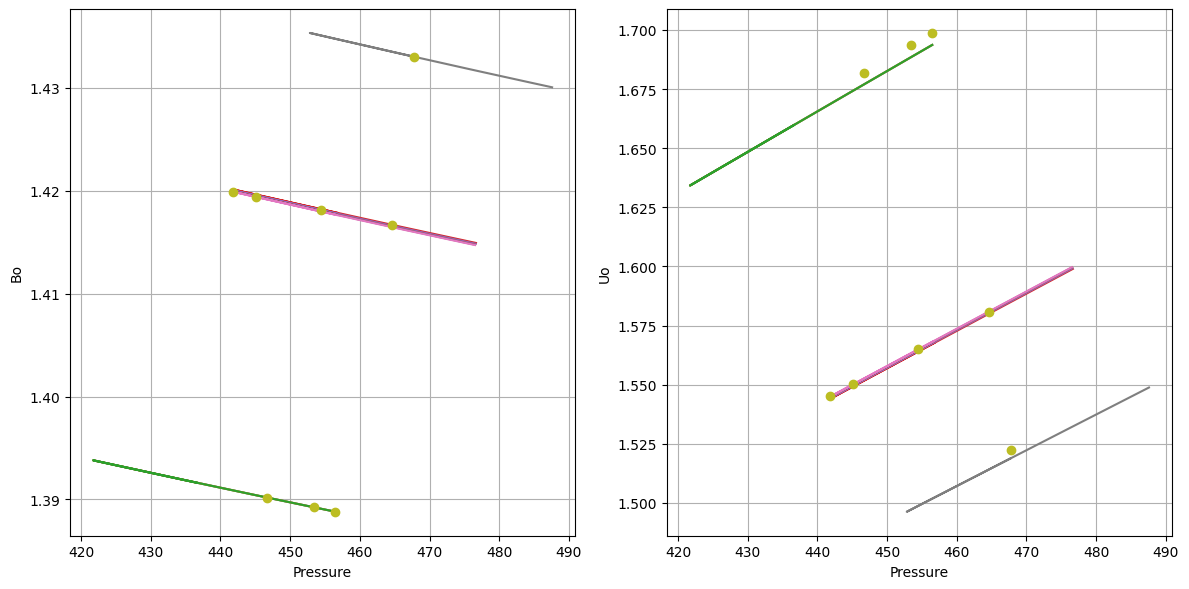

In [13]:
EPS = 1e-6
_, axes = plt.subplots(1,2, figsize=(12, 6))
axes = axes.flatten()

interpolated = {'b': {}, 'u': {}}

extrap_psat = data_['psat']
extrap_deltas = data_['delta_pres']
for ii, p in enumerate(['b','u']):
    i_ = -1 if p == 'u' else 0
    vs = alt_interp1d(
        x=pvt['sat']['PRES'],
        y=pvt['sat'][f'{p.upper()}O'],
        x_new=extrap_psat,
        x_inversion=pvt['sat']['PRES'][i],
        inverse_smaller=(p=='b'),
        extrap=True
        )

    alpha = interp_extrap(alphas[p][0], alphas[p][1], extrap_psat, extrap=False)
    beta = interp_extrap(betas[p][0], betas[p][1], extrap_psat, extrap=False)
    for pr, vs_, alpha_, beta_ in zip(extrap_psat, vs, alpha, beta):
        s = alpha_ * extrap_deltas * beta_ + 1
        s[s < EPS] =  - EPS / extrap_deltas[s < EPS] # avoid negative values inside the power
        new_values = vs_ * np.power(s, 1/alpha_)

        axes[ii].plot(extrap_deltas + pr, new_values, '-')
        interpolated[p][float(pr)] = (extrap_deltas + pr, new_values)

    axes[ii].plot(data_['pres'], data_[f'{p}o_true'], 'o')
    axes[ii].set_xlabel('Pressure')
    axes[ii].set_ylabel(f'{p.upper()}o')

axes[0].grid()
axes[1].grid()
plt.tight_layout()
plt.show()
plt.close()

## Inverse Bo and Uo function

Find the pressure associated with a given Bo or Uo.

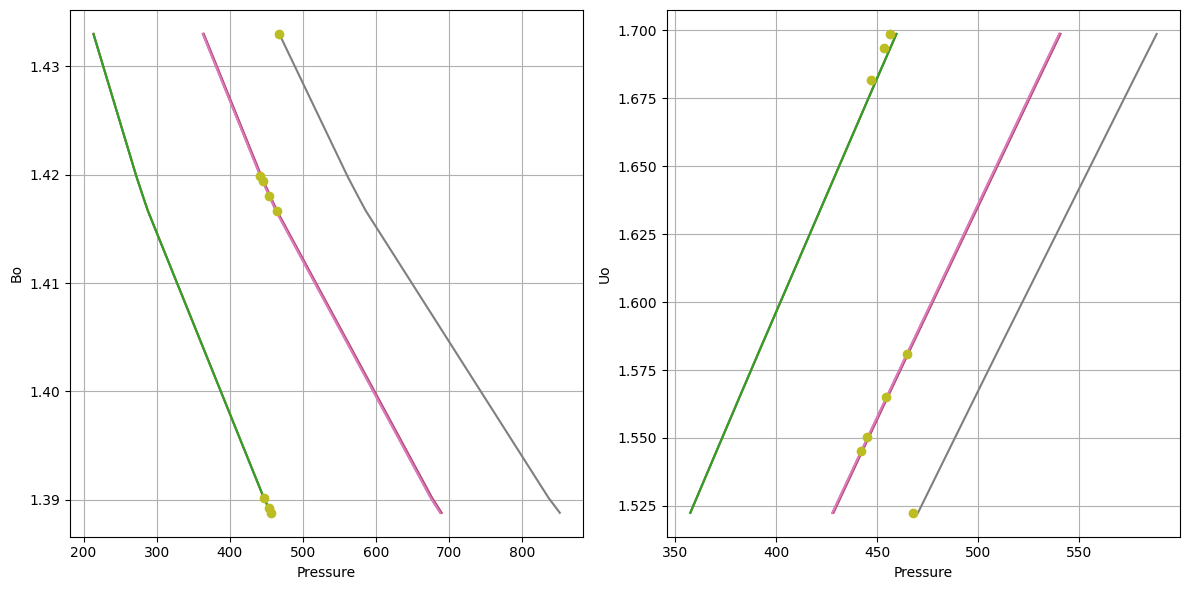

In [14]:
EPS = 1e-6
_, axes = plt.subplots(1,2, figsize=(12, 6))
axes = axes.flatten()
interpolated = {'b': {}, 'u': {}}

extrap_psat = data_['psat']
for ii, p in enumerate(['b','u']):
    extrap_v = data_[f'{p}o_true']

    i_ = -1 if p == 'u' else 0
    vs = alt_interp1d(
        x=pvt['sat']['PRES'],
        y=pvt['sat'][f'{p.upper()}O'],
        x_new=extrap_psat,
        x_inversion=pvt['sat']['PRES'][i],
        inverse_smaller=(p=='b'),
        extrap=True
        )

    alpha = interp_extrap(alphas[p][0], alphas[p][1], extrap_psat, extrap=False)
    beta = interp_extrap(betas[p][0], betas[p][1], extrap_psat, extrap=False)
    for pr, vs_, alpha_, beta_ in zip(extrap_psat, vs, alpha, beta):
        new_values = (np.power(extrap_v / vs_, alpha_) - 1) / (alpha_ * beta_)

        axes[ii].plot(new_values + pr, extrap_v, '-')

    axes[ii].plot(data_['pres'], data_[f'{p}o_true'], 'o')
    axes[ii].set_xlabel('Pressure')
    axes[ii].set_ylabel(f'{p.upper()}o')

axes[0].grid()
axes[1].grid()
plt.tight_layout()
plt.show()
plt.close()

# Instantaneous Equilibrium

Given a porous volume and standard volumes, assume instananeous equilibrium and calculate pressure and solubility ratio.

In [15]:
file_path = Path('../../SimModels/Unisim_iv_2024/dat_bo/base_case_bo.dat')
parser = DatParser(ignore=['ROCKFLUID','INITIAL','NUMERICAL','RUN','GRID_keys'])
parser.process(file_path=file_path)
pvt = dat_pvt.get_from_dat_data(parser.get())[0]

In [16]:
"""Primeiro verifica o erro na p=psat (rs=Vg_std/Vo_std), se for <0, faz erro sempre assumindo p<psat, cc sempre assumindo p>psat."""

def _get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, p, rs=None, psat=None, is_sat=None):
    """Calculate the volume error for a given pressure."""
    if is_sat is None:
        rs = vg_std / (vo_std + 1e-20)
        psat = dat_pvt.get_psat(pvt, rs=rs)
        is_sat = (psat > p)

    if (is_sat).any():
        rs[is_sat] = dat_pvt.get_rs(pvt, psat=p[is_sat])
        psat[is_sat] = p[is_sat]

    vpor = vpor_ref * dat_pvt.get_por_mod(pvt, p=p)
    vo = vo_std * dat_pvt.get_bo(pvt, p=p, rs=rs, psat=psat)
    vg = (vg_std - rs * vo_std) / dat_pvt.get_eg(pvt, p=p)
    vw = vw_std * dat_pvt.get_bw(pvt, p=p)
    v_total = vo + vg + vw
    v_error = v_total - vpor
    return v_error


def find_equilibrium(pvt, vo_std, vg_std, vw_std, vpor_ref, max_iter=10, tol=1e-6):
    """
    Find the equilibrium pressure using the secant method.

    First it is tested the saturation pressure. With this information
    the algorithm can determine if the system is saturated or not.
    The secant method is used to find the equilibrium pressure.

    Arguments
    -----------
    - 'pvt': PVT data dict.
    - 'vo_std': Standard oil volume.
    - 'vg_std': Standard gas volume.
    - 'vw_std': Standard water volume.
    - 'vpor_ref': Reference pore volume.
    - 'max_iter': Maximum number of iterations.
    - 'tol': Tolerance for convergence.

    Returns
    """
    vo_std = np.asarray(vo_std)
    vg_std = np.asarray(vg_std)
    vw_std = np.asarray(vw_std)
    vpor_ref = np.asarray(vpor_ref)

    # Check if equilibrium is saturated or undersaturated
    rs = vg_std / (vo_std + 1e-20)
    psat = dat_pvt.get_psat(pvt, rs=rs)
    error_ = _get_vol_error(
        pvt, vo_std, vg_std, vw_std, vpor_ref,
        p=psat,
        rs=rs,
        psat=psat,
        is_sat=np.zeros_like(psat, dtype=bool)
    )

    print('psat', psat, 'error', error_)

    is_sat = (error_ < 0)
    print('is_sat', is_sat)
    p0 = psat.copy()

    filter_ = psat > pvt['sat']['PRES'].max()
    p0[filter_] = pvt['sat']['PRES'].max()

    e0 = error_.copy()

    e0[filter_] = _get_vol_error(
        pvt, vo_std[filter_], vg_std[filter_], vw_std[filter_], vpor_ref[filter_],
        p=p0[filter_]
    )

    print('p0', p0, 'e0', e0)
    p1 = np.zeros_like(psat)
    if is_sat.any():
        p1[is_sat] = p0[is_sat] - (p0[is_sat] - pvt['sat']['PRES'].min()) / 2
    if (~is_sat).any():
        p1[~is_sat] = p0[~is_sat] + (pvt['sat']['PRES'].max() - p0[~is_sat]) / 2

    # Apply secant method
    for _ in range(max_iter):
        e1 = _get_vol_error(
            pvt, vo_std, vg_std, vw_std, vpor_ref,
            p=p1,
            rs=rs,
            psat=psat,
            is_sat=is_sat
        )
        print('p1', p1, 'e1', e1)

        p_star = np.where(
            np.abs(e1 - e0) < EPS,
            (p0 + p1) / 2,
            (p0 * e1 - p1 * e0) / (e1 - e0)
        )

        print('p_star', p_star)

        if (np.abs(p_star - p1) < tol).all():
            return p_star

        filter_ =  np.abs(e1) < np.abs(e0)
        p0[filter_] = p1[filter_]
        e0[filter_] = e1[filter_]
        p1 = p_star

    return p_star

vo_std = [1., 1., 1.]
vg_std = [200., 400., 200.]
vw_std = [1., 1., 1.]
vpor_ref = [2.5, 5.5, 20.5]

vpor_ref += [2.709194919860055597e+04]
vo_std += [1.803345251508902888e-02]
vg_std += [5.896375884700173512e+06]
vw_std += [9.524661844512485914e+03]

vpor_ref += [1.027793E+04]
vo_std += [0.000000E+00]
vg_std += [0.000000E+00]
vw_std += [9.979238E+03]

vo_std = np.asarray(vo_std)
vg_std = np.asarray(vg_std)
vw_std = np.asarray(vw_std)
vpor_ref = np.asarray(vpor_ref)

p_eq = find_equilibrium(pvt, vo_std, vg_std, vw_std, vpor_ref, max_iter=15, tol=1e-6)
print(p_eq)

vo_std = np.asarray(vo_std)
vg_std = np.asarray(vg_std)
vw_std = np.asarray(vw_std)
vpor_ref = np.asarray(vpor_ref)
_get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, p_eq)

psat [3.45027498e+02 6.22250860e+02 3.45027498e+02 4.52467463e+08
 1.03000000e+00] error [ 3.59982807e-02 -2.59735442e+00 -1.78581894e+01 -6.87401023e+08
  2.59096145e+02]
is_sat [False  True  True  True False]
p0 [345.02749839 550.         345.02749839 550.           1.03      ] e0 [ 3.59982807e-02 -2.54859383e+00 -1.78581894e+01 -1.63209553e+03
  2.59096145e+02]
p1 [447.51374919 275.515      173.02874919 275.515      275.515     ] e1 [ 1.93775835e-03 -2.12272233e+00 -1.73337835e+01  4.70463135e+03
  1.00517139e+02]
p_star [  453.34435821 -1092.63345803 -5512.24026017   479.30329002
   449.50049465]
p1 [  453.34435821 -1092.63345803 -5512.24026017   479.30329002
   449.50049465] e1 [ 1.20044595e-04  1.47282742e+04  3.61991430e+04 -7.50782661e+02
 -1.81898940e-12]
p_star [453.72942054 275.31784311 170.30768877 419.07738641 449.50049465]
p1 [453.72942054 275.31784311 170.30768877 419.07738641 449.50049465] e1 [ 3.92787692e-07 -2.12208770e+00 -1.73171069e+01  2.12006761e+02
  0.00000000e

/tmp/ipykernel_110552/999655610.py:96: RuntimeWarning: invalid value encountered in divide
  (p0 * e1 - p1 * e0) / (e1 - e0)


array([ 1.75403247e-10,  5.40138460e+03,  1.41065031e+04, -2.54658516e-11,
        0.00000000e+00])

In [30]:
_get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, np.array([700.0]))

array([2.38278774e+09])

In [62]:
1.0/(7.033*8534.0 + 0.5415*120000.0 - 537.0*176.0 + 403300.0)*14.22

3.278101835741178e-05

In [60]:
1.0/(7.033*3500.0 + 0.5415*74289.3 - 537.0*165.0 + 403300.0)

2.6347812053229746e-06

In [53]:
def _get_vol_error_debug(pvt, vo_std, vg_std, vw_std, vpor_ref, p, rs=None, psat=None, is_sat=None):
    """Calculate the volume error for a given pressure."""
    if is_sat is None:
        rs = vg_std / (vo_std + 1e-20)
        psat = dat_pvt.get_psat(pvt, rs=rs)
        is_sat = (psat > p)

    if (is_sat).any():
        rs[is_sat] = dat_pvt.get_rs(pvt, psat=p[is_sat])
        psat[is_sat] = p[is_sat]

    vpor = vpor_ref * dat_pvt.get_por_mod(pvt, p=p)
    vo = vo_std * dat_pvt.get_bo(pvt, p=p, rs=rs, psat=psat)
    vg = (vg_std - rs * vo_std) / dat_pvt.get_eg(pvt, p=p)
    vw = vw_std * dat_pvt.get_bw(pvt, p=p)
    v_total = vo + vg + vw
    v_error = v_total - vpor
    return v_error, v_total, vpor, vo, vg, vw, rs


# vpor_ref = [1.0]
# vo_std = [400.0]
# vg_std = [1.0]
# vw_std = [5.5]
# vpor_ref = [2.709194919860055597e+04]
# vo_std = [1.803345251508902888e-02]
# vg_std = [5.896375884700173512e+06]
# vw_std = [9.524661844512485914e+03]

vpor_ref = [1.027793E+04]
vo_std = [0.000000E+00]
vg_std = [0.000000E+00]
vw_std = [9.979238E+03]

vo_std = np.asarray(vo_std)
vg_std = np.asarray(vg_std)
vw_std = np.asarray(vw_std)
vpor_ref = np.asarray(vpor_ref)

n = 100
vo_std = np.repeat(vo_std, n)
vg_std = np.repeat(vg_std, n)
vw_std = np.repeat(vw_std, n)
vpor_ref = np.repeat(vpor_ref, n)

p = np.linspace(50, 700, n)
v_error, v_total, vpor, vo, vg, vw, rs = _get_vol_error_debug(pvt, vo_std, vg_std, vw_std, vpor_ref, p)
# print(p,v_error)

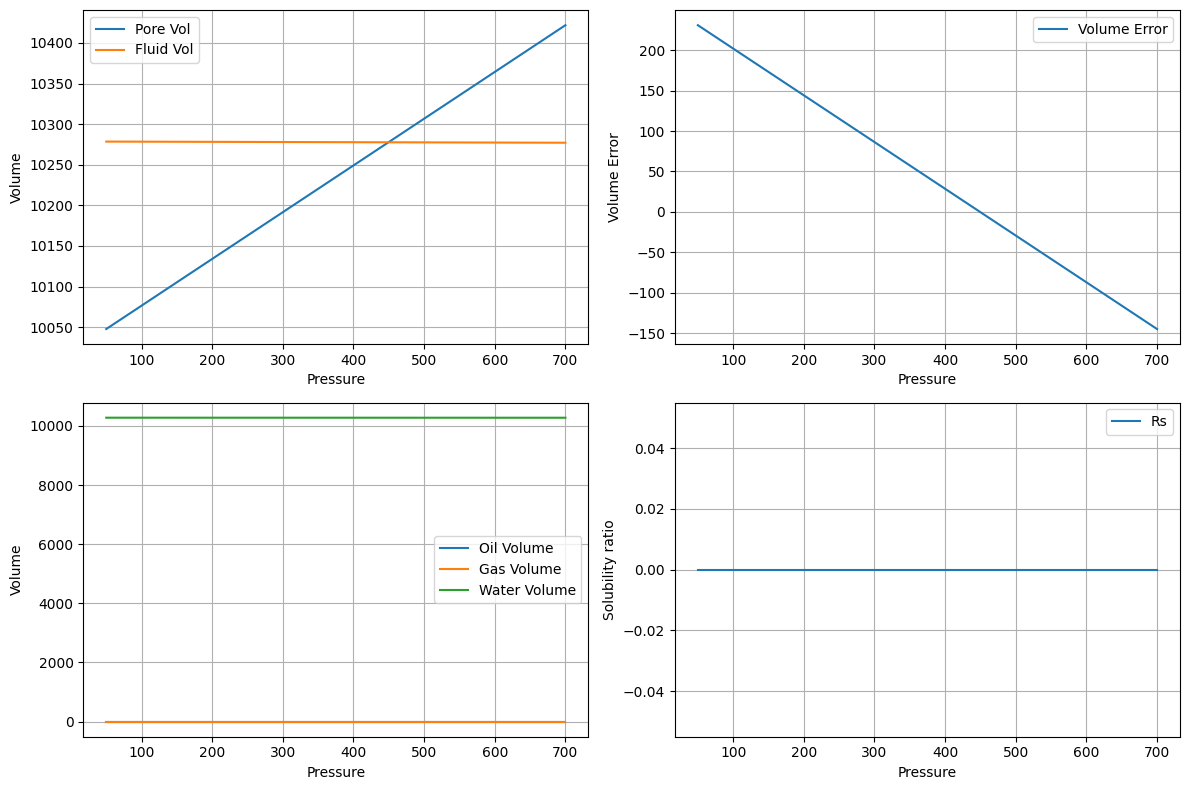

In [55]:
_, axes = plt.subplots(2,2, figsize=(12, 8))
axes = axes.flatten()

axes[0].plot(p, vpor, label='Pore Vol')
axes[0].plot(p, v_total, label='Fluid Vol')
# axes[0].set_ylim(0, vpor.max())
axes[0].set_xlabel('Pressure')
axes[0].set_ylabel('Volume')

axes[1].plot(p, v_error, label='Volume Error')
axes[1].set_xlabel('Pressure')
axes[1].set_ylabel('Volume Error')

axes[2].plot(p, vo, label='Oil Volume')
axes[2].plot(p, vg, label='Gas Volume')
axes[2].plot(p, vw, label='Water Volume')
axes[2].set_xlabel('Pressure')
axes[2].set_ylabel('Volume')

axes[3].plot(p, rs, label='Rs')
axes[3].set_xlabel('Pressure')
axes[3].set_ylabel('Solubility ratio')

for ax in axes:
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()
plt.close()

In [56]:
pvt

{'sat':       PRES        RS      BO          EG      UO       UG
 0     1.03    0.0000  1.0154    0.877593  7.6806  0.01170
 1    35.00   24.8808  1.0884   32.351990  3.9777  0.01492
 2    70.00   44.3856  1.1379   68.587106  3.1474  0.01628
 3   110.00   65.6315  1.1893  113.378685  2.5602  0.01843
 4   150.00   86.7313  1.2388  158.730159  2.1668  0.02161
 5   190.00  108.0469  1.2877  201.207243  1.8833  0.02589
 6   230.00  129.9178  1.3370  237.529691  1.6656  0.03095
 7   270.00  152.7532  1.3877  268.096515  1.4887  0.03638
 8   310.00  177.0238  1.4412  292.397661  1.3383  0.04191
 9   350.00  203.2617  1.4985  311.526480  1.2057  0.04743
 10  392.29  233.8234  1.5649  327.868852  1.0798  0.05335
 11  400.00  239.3935  1.5770  331.125828  1.0580  0.05443
 12  415.00  250.2331  1.6005  336.700337  1.0165  0.05656
 13  430.00  261.0726  1.6241  341.296928  0.9762  0.05869
 14  450.00  275.5254  1.6554  347.222222  0.9242  0.06156
 15  470.00  289.9781  1.6868  353.356890  0.8742

In [ ]:
def binary_intersection(g_func, x_min=0.0, x_max=1.0, tol=1e-5, max_iter=50):
    """
    g_func: nn.Module, recebe tensor shape [batch, 1]
    x_min, x_max: limites de busca
    tol: tolerância para parada
    max_iter: máximo de iterações
    """
    if x_min < x_max:
        left, right = x_min, x_max
    elif x_min > x_max:
        right, left = x_min, x_max
    else:
        return x_min

    g_left = g_func(left)
    g_right = g_func(right)

    if g_left * g_right > 0:
        delta = (right - left)
        right = right + delta * 0.5
        left = left - delta * 0.5
        g_left = g_func(left)
        g_right = g_func(right)

        if g_left * g_right > 0:
            raise ValueError("Funções não se cruzam no intervalo fornecido.")

    for _ in range(max_iter):
        mid = (left + right) / 2
        g_mid = g_func(mid)

        if (right - left) < tol:
            return mid

        if g_left * g_mid < 0:
            right = mid
            g_right = g_mid
        else:
            left = mid
            g_left = g_mid

    return mid  # Valor após max_iter

vo_std = 1.
vg_std = 400.
vw_std = 1.
vpor_ref = 20.5

def g_func(x):
    return get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, x)[0]

# g_func(np.array([250.0]))

x_star = binary_intersection(g_func, x_min=np.array([250.0]), x_max=np.array([1000.0]), tol=1e-5, max_iter=50)
y_star = g_func(x_star)

print(x_star, y_star)


[622.1875893] [-0.00018197]


In [ ]:
def do_secant_search(g_func, x_try, tol=1e-5, max_iter=50):
    y_try = g_func(x_try)
    y_abs = np.abs(y_try)
    idx = np.argsort(y_abs)[:2]
    x = x_try[idx]
    y = y_try[idx]

    print(x,y)

    for _ in range(max_iter):
        if np.abs(y[0]) < tol:
            return x[0]
        if np.abs(y[1]) < tol:
            return x[1]

        # Secant method step
        x_star = (x[0] * y[1] - x[1] * y[0]) / (y[1] - y[0])
        y_star = g_func(np.array([x_star]))[0]

        if np.abs(y_star) < tol:
            return x_star

        # Replace the point with the highest error
        if np.abs(y[0]) > np.abs(y[1]):
            x[0] = x_star
            y[0] = y_star
        else:
            x[1] = x_star
            y[1] = y_star

    return x_star


vo_std = 1.
vg_std = 400.
vw_std = 1.
vpor_ref = 5.5
def g_func(x):
    return get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, x)[0]
x_star = do_secant_search(g_func, x_try=np.linspace(250.0, 1000.0, 10), tol=1e-5, max_iter=40)
y_star = g_func(np.array([x_star]))
print(x_star, y_star)

vo_std = 1.
vg_std = 200.
vw_std = 1.
vpor_ref = 2.5
def g_func(x):
    return get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, x)[0]
x_star = do_secant_search(g_func, x_try=np.linspace(250.0, 1000.0, 10), tol=1e-5, max_iter=40)
y_star = g_func(np.array([x_star]))
print(x_star, y_star)

vo_std = 1.
vg_std = 200.
vw_std = 1.
vpor_ref = 2000.5
def g_func(x):
    return get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, x)[0]
x_star = do_secant_search(g_func, x_try=np.linspace(250.0, 1000.0, 10), tol=1e-5, max_iter=40)
y_star = g_func(np.array([x_star]))
print(x_star, y_star)


[666.66666667 750.        ] [-2.62313388 -2.66868513]
-4117.451396233701 [-4.19827765e-07]
[416.66666667 500.        ] [ 0.01174909 -0.01404476]
453.74851436632355 [-5.53904859e-06]
[333.33333333 416.66666667] [  343.58026537 -1994.25865091]
335.08532178015986 [2.56911721e-06]


In [ ]:
vo_std = 1.
vg_std = 200.
vw_std = 1.
vpor_ref = 20.5


x = np.array([[250, 300],[650, 700]])
y = get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, x)[0]
print(x)
print(y)

x_star = (x[:,0]*y[:,1]-x[:,1]*y[:,0])/(y[:,1]-y[:,0])
print(x_star)
# if x_star < 100:
#     x = np.array([250, 300])
#     y = get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, x)[0]
#     print(x, y)
#     x_star = (x[0]*y[1]-x[1]*y[0])/(y[1]-y[0])

y_star = get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, np.array([x_star]))[0]
print(x_star, y_star)


# step
x = np.array([x_star, x[0]])
y = get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, x)[0]
x_star = (x[0]*y[1]-x[1]*y[0])/(y[1]-y[0])
y_star = get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, np.array([x_star]))[0]
print(x_star, y_star)

# step
x = np.array([x_star, x[0]])
y = get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, x)[0]
x_star = (x[0]*y[1]-x[1]*y[0])/(y[1]-y[0])
y_star = get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, np.array([x_star]))[0]
print(x_star, y_star)

# step
x = np.array([x_star, x[0]])
y = get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, x)[0]
x_star = (x[0]*y[1]-x[1]*y[0])/(y[1]-y[0])
y_star = get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, np.array([x_star]))[0]
print(x_star, y_star)

# step
x = np.array([x_star, x[0]])
y = get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, x)[0]
x_star = (x[0]*y[1]-x[1]*y[0])/(y[1]-y[0])
y_star = get_vol_error(pvt, vo_std, vg_std, vw_std, vpor_ref, np.array([x_star]))[0]
print(x_star, y_star)

print(x_star[x_star > 0].mean())

[[250 300]
 [650 700]]
[[14850.12189589  8562.12996002]
 [  -18.25750491   -18.32088857]]
[   368.08318178 -13752.37422205]
[   368.08318178 -13752.37422205] [[-17.88948242  -2.68214189]]
[   367.94074881 -13747.83359439] [[-17.88928988  -2.68719761]]
[-12865.44336013 -16161.2509298 ] [[-3.66758282  0.01245653]]
[-16278.15126902 -16150.11512814] [[ 1.43757375e-01 -4.88446707e-05]]
[-16149.42963684 -16150.15862339] [[-8.18630949e-04 -7.50434159e-10]]
nan


/tmp/ipykernel_24079/2963804462.py:52: RuntimeWarning: Mean of empty slice.
  print(x_star[x_star > 0].mean())
/home/tiago/dev/simpython/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
